In [1]:
import os
import pandas as pd

def construct_dataset_from_directories(path_list, max_files):
    records = []

    for idx, directory in enumerate(path_list):
        if not os.path.isdir(directory):
            continue

        file_count = 0
        label = 1 if idx == 0 else 0  # first directory = cooking

        for filename in sorted(os.listdir(directory)):
            if file_count >= max_files:
                break

            if filename.endswith(".txt"):
                file_path = os.path.join(directory, filename)

                try:
                    with open(file_path, "r", encoding="utf-8") as f:
                        text = f.read()

                    records.append({
                        "title": filename,
                        "text": text,
                        "is_cooking": label
                    })

                    file_count += 1

                except Exception as e:
                    print(f"Skipping {file_path}: {e}")

    return pd.DataFrame(records)

In [2]:
import re

def simple_token_count(text):
    return len(text.split())


def split_by_token_limit(text, max_token):
    words = text.split()
    chunks = []

    for i in range(0, len(words), max_token):
        chunk = " ".join(words[i:i + max_token])
        chunks.append(chunk)

    return chunks


def is_numeric_only(text):
    return bool(re.fullmatch(r"[\d\s\W]+", text))


def basic_preprocess(text):
    text = text.strip()
    text = re.sub(r"\s+", " ", text)  # normalize whitespace
    return text
def divide_and_preprocess_dataframe(df, column_name, max_token):
    import re

    def simple_token_count(text):
        return len(text.split())

    def split_by_token_limit(text, max_token):
        words = text.split()
        return [
            " ".join(words[i:i + max_token])
            for i in range(0, len(words), max_token)
        ]

    def is_numeric_only(text):
        return bool(re.fullmatch(r"[\d\s\W]+", text))

    def basic_preprocess(text):
        text = text.strip()
        text = re.sub(r"\s+", " ", text)
        return text

    processed_rows = []

    for _, row in df.iterrows():
        title = row["title"]
        text = row[column_name]
        label = row["is_cooking"]

        initial_chunks = re.split(r"\n\s*\n", text)
        chunk_id = 0

        for chunk in initial_chunks:
            chunk = basic_preprocess(chunk)

            if not chunk:
                continue

            if simple_token_count(chunk) > max_token:
                sub_chunks = split_by_token_limit(chunk, max_token)
            else:
                sub_chunks = [chunk]

            for sub_chunk in sub_chunks:
                sub_chunk = basic_preprocess(sub_chunk)

                if not sub_chunk or is_numeric_only(sub_chunk):
                    continue

                processed_rows.append({
                    "title": title,
                    "chunk_id": chunk_id,
                    "chunk": sub_chunk,
                    "is_cooking": label
                })

                chunk_id += 1

    return pd.DataFrame(processed_rows)

In [3]:
paths = ['data/archive-americana-cookbook-download-desc', 'data/archive-americana-fiction-literature-technology-download-desc']
df = construct_dataset_from_directories(paths, 10)

In [4]:
df.describe()

,is_cooking
count,20.000000
mean,0.500000
std,0.512989
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [5]:
df = divide_and_preprocess_dataframe(df, 'text', 256)

In [6]:
df.head()

,title,chunk_id,chunk,is_cooking
0,100thriftrecipes00unse_djvu.txt,0,TX 357 .06,1
1,100thriftrecipes00unse_djvu.txt,1,Copy 1,1
2,100thriftrecipes00unse_djvu.txt,2,ioo Thrift Tripes,1
3,100thriftrecipes00unse_djvu.txt,3,That Use Little Wheat Meaty Fat and Sugar,1
4,100thriftrecipes00unse_djvu.txt,4,Gingerbread. Made With Drippings,1


In [7]:
import numpy as np
from tqdm import tqdm

def embed_df(df, embedding_model, embedding_model_name, column_name, batch_size=32):
    """
    Compute embeddings in batches for a given text column.
    Works with MiniLM / SentenceTransformers models.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    df = df.copy()
    texts = df[column_name].fillna("").tolist()
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding ({embedding_model_name})"):
        batch = texts[i:i + batch_size]

        try:
            batch_embeddings = embedding_model(batch)

            if len(batch_embeddings) != len(batch):
                raise ValueError("Embedding model returned mismatched batch size")

        except Exception as e:
            print(f"Batch failed at index {i}: {e}")
            batch_embeddings = [None] * len(batch)

        all_embeddings.extend(batch_embeddings)

    df[embedding_model_name] = all_embeddings
    return df

In [8]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
#gemma = SentenceTransformer("google/embeddinggemma-300m")

/Users/yavuzlule/Desktop/bsc-thesis-copy/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2018.78it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
df.head()

,title,chunk_id,chunk,is_cooking
0,100thriftrecipes00unse_djvu.txt,0,TX 357 .06,1
1,100thriftrecipes00unse_djvu.txt,1,Copy 1,1
2,100thriftrecipes00unse_djvu.txt,2,ioo Thrift Tripes,1
3,100thriftrecipes00unse_djvu.txt,3,That Use Little Wheat Meaty Fat and Sugar,1
4,100thriftrecipes00unse_djvu.txt,4,Gingerbread. Made With Drippings,1


In [10]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Initialize your embedding model

def add_embeddings(df, batch_size=32):
    """
    Adds embeddings for the 'chunk' column in batches and stores them in 'mini_lm'.

    Args:
        df (pd.DataFrame): DataFrame containing 'chunk' column.
        batch_size (int): Number of rows to process per batch.

    Returns:
        pd.DataFrame: Original df with new 'mini_lm' column.
    """
    embeddings = []

    # Iterate in batches
    for start in range(0, len(df), batch_size):
        end = start + batch_size
        batch_texts = df["chunk"].iloc[start:end].tolist()
        batch_embeddings = embedding_model.encode(batch_texts, show_progress_bar=False)
        embeddings.extend(batch_embeddings)
    
    df["mini_lm"] = embeddings
    return df

# Example usage:
# df = add_embeddings(df, batch_size=2)

In [11]:
df = add_embeddings(df, batch_size=32)

# Now convert numpy arrays to lists if you need
#df["mini_lm"] = df["mini_lm"].apply(lambda x: x.tolist())

In [12]:
df.head()

,title,chunk_id,chunk,is_cooking,mini_lm
0,100thriftrecipes00unse_djvu.txt,0,TX 357 .06,1,"[-0.03474204, 0.06812331, 0.029666206, 0.10110..."
1,100thriftrecipes00unse_djvu.txt,1,Copy 1,1,"[-0.101963475, -0.05137961, -0.039843313, -0.0..."
2,100thriftrecipes00unse_djvu.txt,2,ioo Thrift Tripes,1,"[-0.06438677, 0.05443256, 0.010624982, 0.05215..."
3,100thriftrecipes00unse_djvu.txt,3,That Use Little Wheat Meaty Fat and Sugar,1,"[-0.03930794, 0.011759741, -0.0029531908, 0.07..."
4,100thriftrecipes00unse_djvu.txt,4,Gingerbread. Made With Drippings,1,"[-0.11969797, 0.0050870273, -0.0107092345, 0.0..."


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Assume df['mini_lm'] contains lists
X = np.array(df['mini_lm'].tolist())  # Convert list embeddings to numpy array
y = df['is_cooking'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', max_iter=1000),
    #'SVM': SVC(probability=True, kernel='linear'),
    #'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    results[name] = model  # Save trained model if needed

=== Logistic Regression ===
Accuracy: 0.9086
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     13634
           1       0.90      0.87      0.88      9051

    accuracy                           0.91     22685
   macro avg       0.91      0.90      0.90     22685
weighted avg       0.91      0.91      0.91     22685



In [14]:
import joblib

# Save each trained model
for name, model in results.items():
    # Replace spaces with underscores for file name
    filename = f"{name.replace(' ', '_3')}.joblib"
    joblib.dump(model, filename)
    print(f"Saved {name} to {filename}")

Saved Logistic Regression to Logistic_3Regression.joblib


In [21]:
paths = ['data/archive-americana-cookbook-download-desc', 'data/archive-americana-fiction-literature-technology-download-desc']
v_df = construct_dataset_from_directories(paths, 50)
v_df = divide_and_preprocess_dataframe(v_df, 'text', 256)
v_df = add_embeddings(v_df, batch_size=64)
# Make sure X contains the embeddings
X = np.array(v_df['mini_lm'].tolist())

# Add probability scores from each model
for name, model in models.items():
    # Generate probabilities for the positive class (assumes binary classification)
    probs = model.predict_proba(X)[:, 1]
    
    # Create a new column with model name + '_score'
    col_name = f"{name.replace(' ', '_')}_score"
    v_df[col_name] = probs

# Inspect the updated DataFrame
print(v_df.head())

                             title  chunk_id  \
0  100thriftrecipes00unse_djvu.txt         0   
1  100thriftrecipes00unse_djvu.txt         1   
2  100thriftrecipes00unse_djvu.txt         2   
3  100thriftrecipes00unse_djvu.txt         3   
4  100thriftrecipes00unse_djvu.txt         4   

                                       chunk  is_cooking  \
0                                 TX 357 .06           1   
1                                     Copy 1           1   
2                          ioo Thrift Tripes           1   
3  That Use Little Wheat Meaty Fat and Sugar           1   
4           Gingerbread. Made With Drippings           1   

                                             mini_lm  \
0  [-0.034742087, 0.068123356, 0.029666139, 0.101...   
1  [-0.10196346, -0.051379617, -0.039843276, -0.0...   
2  [-0.06438679, 0.05443255, 0.010624915, 0.05215...   
3  [-0.03930794, 0.011759741, -0.0029531908, 0.07...   
4  [-0.11969789, 0.005087059, -0.010709253, 0.056...   

   Logistic_R

In [22]:
filtered_pivot = v_df.pivot(
    index="title",
    columns="chunk_id",
    values="Logistic_Regression_score"
)

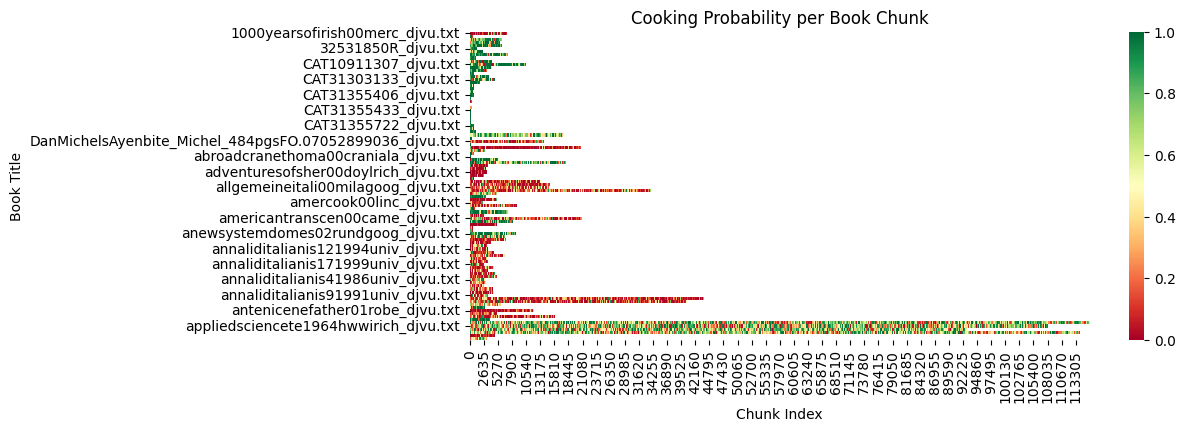

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(filtered_pivot, cmap="RdYlGn", vmin=0, vmax=1)

plt.xlabel("Chunk Index")
plt.ylabel("Book Title")
plt.title("Cooking Probability per Book Chunk")

plt.show()

In [ ]:
import datetime

# Set your threshold and model
threshold = 0.7
model_name = "Logistic_Regression"
score_col = f"{model_name.replace(' ', '_')}_score"

# Filter chunks above the threshold
filtered_df = v_df[v_df[score_col] > threshold]

# Create a timestamp string
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Build unique output filename
output_file = f"chunks_above_{threshold}_{model_name}_{timestamp}.txt"

# Save filtered chunks
with open(output_file, "w", encoding="utf-8") as f:
    for chunk in filtered_df["chunk"]:
        f.write(chunk + "\n")

print(f"Saved {len(filtered_df)} chunks to {output_file}")